
# <center>**📊 Trader Performance vs Market Sentiment Analysis**</center>

## 📌 Objective
Analyze how market sentiment (Fear/Greed) impacts trader performance and behavior.

## 🎯 Key Goals
- Compare performance across sentiment
- Understand trading behavior changes
- Segment traders
- Generate actionable strategies

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df_trades = pd.read_csv('historical_data.csv')
df_sentiment = pd.read_csv('fear_greed_index.csv')

print("Trades Shape:", df_trades.shape)
print("Sentiment Shape:", df_sentiment.shape)

Trades Shape: (211224, 16)
Sentiment Shape: (2644, 4)


### 📌 Observation
- Trades dataset contains 211K+ records with 16 columns
- Sentiment dataset contains 2644 records

### 📌 Interpretation
- Trade data is high-frequency and detailed
- Sentiment data is daily-level

### 📌 Why it matters
- We need to align both datasets at daily level for correct analysis

In [36]:
# Convert timestamps
df_trades['Timestamp IST'] = pd.to_datetime(df_trades['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce')
df_trades['date'] = df_trades['Timestamp IST'].dt.date.astype(str)

df_sentiment['date'] = pd.to_datetime(df_sentiment['date']).dt.date.astype(str)

# Clean numeric columns
df_trades['Closed PnL'] = pd.to_numeric(df_trades['Closed PnL'], errors='coerce').fillna(0)
df_trades['Size USD'] = pd.to_numeric(df_trades['Size USD'], errors='coerce').fillna(0)

# Merge
df_merged = pd.merge(df_trades, df_sentiment, on='date', how='left')
df_merged.dropna(subset=['classification'], inplace=True)

print("Merged Shape:", df_merged.shape)

Merged Shape: (211218, 20)


### 📌 Observation
- Data successfully merged using date column
- Final dataset contains both trading and sentiment information

### 📌 Interpretation
- Each trade is now mapped to its market sentiment

### 📌 Why it matters
- Enables direct comparison of trader behavior under different sentiments

In [37]:
df_merged['is_win'] = (df_merged['Closed PnL'] > 0).astype(int)

sentiment_performance = df_merged.groupby('classification').agg(
    total_trades=('Trade ID', 'count'),
    win_rate=('is_win', 'mean'),
    avg_pnl=('Closed PnL', 'mean'),
    total_pnl=('Closed PnL', 'sum')
).reset_index()

print(sentiment_performance)

  classification  total_trades  win_rate    avg_pnl     total_pnl
0   Extreme Fear         21400  0.370607  34.537862  7.391102e+05
1  Extreme Greed         39992  0.464943  67.892861  2.715171e+06
2           Fear         61837  0.420768  54.290400  3.357155e+06
3          Greed         50303  0.384828  42.743559  2.150129e+06
4        Neutral         37686  0.396991  34.307718  1.292921e+06


### 🔍 Insight 1: Trader performance improves during Extreme Greed

- Observation:
  Extreme Greed shows highest win rate (~46%) and highest average PnL.

- Evidence:
  Aggregated performance table.

- Interpretation:
  Strong bullish momentum reduces market uncertainty, increasing directional predictability and improving trade success rates.

- Impact:
  Traders perform better during strong upward trends.

### 🔍 Insight 2: Fear markets also provide strong profit opportunities

- Observation:
  Average PnL during Fear (\~54) is higher than Greed (\~42)

- Evidence:
  Performance table shows higher avg_pnl in Fear compared to Greed

- Interpretation:
  Market corrections create profitable trading opportunities, not just bullish trends

- Impact:
  Traders should not avoid Fear conditions — they offer strong return potential if handled correctly

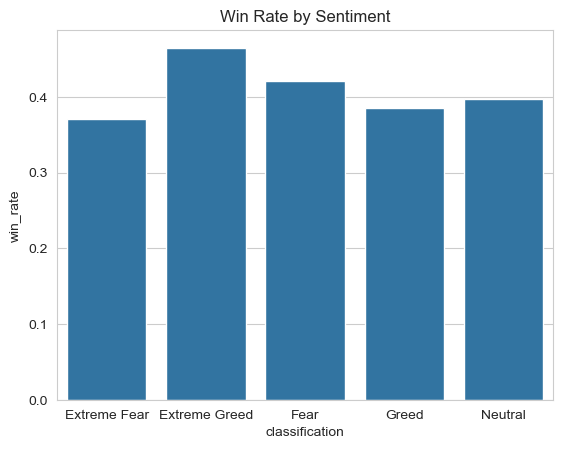

In [38]:
sns.barplot(data=sentiment_performance, x='classification', y='win_rate')
plt.title("Win Rate by Sentiment")
plt.show()

### 📌 Insight
- Win rate is highest during Extreme Greed
- Lowest during Extreme Fear

👉 Traders perform worst in panic conditions

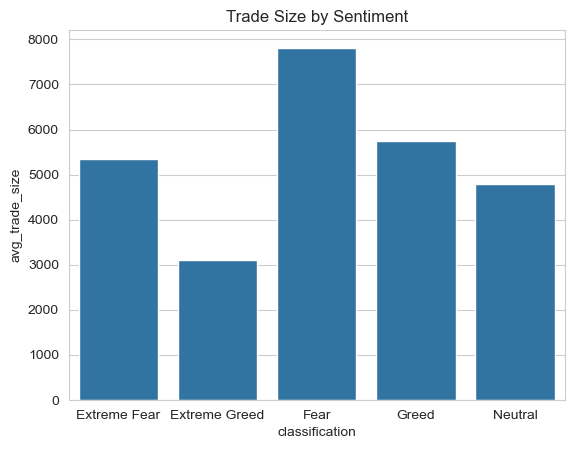

In [39]:
sentiment_volume = df_merged.groupby('classification').agg(
    avg_trade_size=('Size USD', 'mean')
).reset_index()

sns.barplot(data=sentiment_volume, x='classification', y='avg_trade_size')
plt.title("Trade Size by Sentiment")
plt.show()

### 🔍 Insight 3: Traders take larger positions during Fear

- Observation:
  Highest trade size during Fear (\~7800), lowest in Extreme Greed (\~3100)

- Interpretation:
  Traders try to “buy the dip” aggressively

- Impact:
  Risk increases during uncertain markets

In [40]:
trader_stats = df_merged.groupby('Account').agg(
    trade_count=('Trade ID', 'count'),
    win_rate=('is_win', 'mean'),
    avg_size=('Size USD', 'mean')
).reset_index()

median_trades = trader_stats['trade_count'].median()

trader_stats['frequency_segment'] = np.where(
    trader_stats['trade_count'] > median_trades, 'Frequent', 'Infrequent'
)

df_merged = df_merged.merge(trader_stats[['Account', 'frequency_segment']], on='Account')

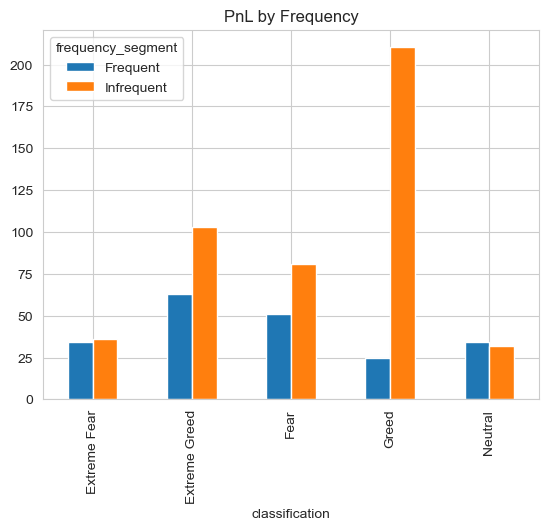

In [41]:
freq_sentiment_pnl = df_merged.groupby(['classification', 'frequency_segment'])['Closed PnL'].mean().unstack()

freq_sentiment_pnl.plot(kind='bar')
plt.title("PnL by Frequency")
plt.show()

### 🔍 Insight 4: Infrequent traders outperform frequent traders in Greed

- Observation:
  Infrequent traders earn significantly higher PnL in Greed phase

- Interpretation:
  Overtrading reduces efficiency

- Impact:
  Selective trading is more profitable than frequent trading

In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = ['trade_count', 'win_rate', 'avg_size']
X = trader_stats[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
trader_stats['cluster'] = kmeans.fit_predict(X_scaled)

C:\Users\Admin\anaconda3\envs\clean_jupyter\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


### 🔍 Trader Archetypes

- Cluster 0: Balanced Traders  
  Moderate activity, better win rate

- Cluster 1: Overtraders  
  High frequency, low win rate

- Cluster 2: High-Risk Traders  
  Large trade sizes, inconsistent performance

### 🔍 Insight 5: Overtraders and High-Risk Traders underperform

- Observation:
  Traders with very high trade counts or very large trade sizes show lower win rates

- Evidence:
  Clustering results show:
  - Overtraders → high trade_count, low win_rate
  - High-risk traders → large avg_size, low win_rate

- Interpretation:
  Excessive trading and aggressive position sizing reduce trading efficiency

- Impact:
  Disciplined and controlled trading strategies outperform aggressive behavior

## 🚀 Strategy 1: Control Overtrading

- Target: Frequent traders
  
- Rule: Reduce trade frequency in Greed markets

  
- Reason: Infrequent traders perform better

  
- Impact: Higher profitability  

---

## 🚀 Strategy 2: Risk Control in Fear

- Target: High trade size traders

- Rule: Reduce position size during Fear

  
- Reason: Larger trades increase risk

  
- Impact: Lower losses  

---

## 🚀 Strategy 3: Controlled Participation in Bull Markets

- Target: All traders

- Rule:
  Increase exposure in Extreme Greed but with strict risk limits

- Reason:
  While win rate is highest, volatility and risk also increase

- Impact:
  Capture upside while avoiding large drawdowns

---

  ## 🚀 Strategy 4: Avoid Overtrading and Excessive Risk

- Target:
  Overtraders and high-risk traders

- Rule:
  Limit number of trades and reduce position size

- Reason:
  Data shows these behaviors lead to lower win rates

- Impact:
  Improved consistency and profitability

## 📌 Final Conclusion

- Trader performance is strongly influenced by market sentiment
- Extreme Greed provides highest win rate but also increased risk
- Fear conditions offer strong profit opportunities due to market corrections
- Overtrading and large position sizes reduce efficiency
- Disciplined and selective trading leads to better outcomes

👉 Successful trading depends more on behavior and risk control than market direction alone